## ДЗ 3


#### Часть 1 — Доделываем семинар и получаем SNP — 3 балла


In [6]:
!cd data

In [ ]:

!wget -O ecoli_k12.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
!wget -O ecoli_o157.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"
!gunzip *.fna.gz

Быстренько делаем часть с семинара

In [1]:

!nucmer --prefix=ecoli_full ~/bioinf/hw_bioinformatics/hw3/data/ecoli_k12.fna ~/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "ecoli_full.ntref" of length 4641653
# construct suffix tree for sequence of length 4641653
# (maximum reference length is 2305843009213693948)
# (maximum query length is 18446744073709551615)
# process 46416 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_full.ntref 3.62
# reading input file "/home/khokholmongolll/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna" of length 5594607
# matching query-file "/home/khokholmongolll/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna"
# against subject-file "ecoli_full.ntref"
# COMPLETETIME /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_full.ntref 14.18
# SPACE /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_full.ntref 9.90
4: FINISHING DATA


In [2]:
!nucmer --prefix=ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12 ~/bioinf/hw_bioinformatics/hw3/data/ecoli_k12.fna ~/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "ecoli_opt.ntref" of length 4641653
# construct suffix tree for sequence of length 4641653
# (maximum reference length is 2305843009213693948)
# (maximum query length is 18446744073709551615)
# process 46416 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_opt.ntref 3.56
# reading input file "/home/khokholmongolll/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna" of length 5594607
# matching query-file "/home/khokholmongolll/bioinf/hw_bioinformatics/hw3/data/ecoli_o157.fna"
# against subject-file "ecoli_opt.ntref"
# COMPLETETIME /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_opt.ntref 14.17
# SPACE /home/khokholmongolll/miniconda3/envs/ml/opt/mummer-3.23/mummer ecoli_opt.ntref 9.90
4: FINISHING DATA


In [4]:
!delta-filter -1 -i 90 ecoli_full.delta > ecoli_full_filt1.delta
!delta-filter -1 -l 5000 ecoli_full.delta > ecoli_full_filt2.delta
!delta-filter -m -i 85 ecoli_full.delta > ecoli_full_multi.delta
!echo "=== Фильтр 1 (1-to-1, id>90%) ==="
!show-coords -r ecoli_full_filt1.delta | wc -l
!echo "=== Фильтр 2 (1-to-1, len>5kb) ==="
!show-coords -r ecoli_full_filt2.delta | wc -l

=== Фильтр 1 (1-to-1, id>90%) ===
335
=== Фильтр 2 (1-to-1, len>5kb) ===
214


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
def load_coords(filename):
    df = pd.read_csv(filename, sep='\t', skiprows=4, 
                     names=['S1', 'E1', 'S2', 'E2', 'LEN1', 'LEN2', 'IDY', 'REF', 'QUERY'])
    return df

In [27]:
!show-coords -r -T ecoli_full_filt1.delta > filt1.tsv
!show-coords -r -T ecoli_full_filt2.delta > filt2.tsv
!show-coords -r -T ecoli_full_multi.delta > filt3.tsv

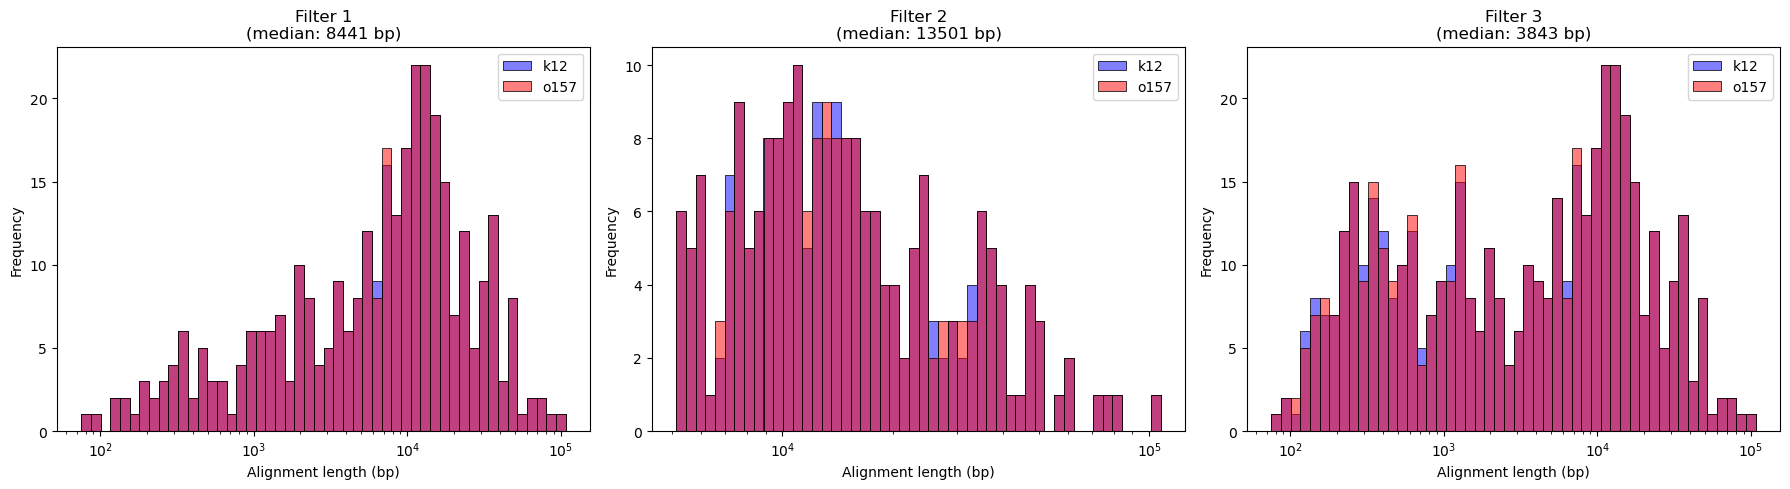

In [38]:
files = {
    "Filter 1": "filt1.tsv", 
    "Filter 2": "filt2.tsv", 
    "Filter 3": "filt3.tsv" 
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, filename) in zip(axes, files.items()):
    df = load_coords(filename)
    
    median_val = df['LEN1'].median()
    
    sns.histplot(data=df, x='LEN1', bins=50, log_scale=True, 
                 color='blue', edgecolor='black', alpha=0.5, label = 'k12', ax=ax)
    
    sns.histplot(data=df, x='LEN2', bins=50, log_scale=True, 
                 color='red', edgecolor='black', alpha=0.5, label = 'o157', ax=ax)
    
    ax.set_title(f"{title}\n(median: {int(median_val)} bp)")
    ax.set_xlabel("Alignment length (bp)")
    ax.set_ylabel("Frequency")
    ax.legend(loc='best')


plt.tight_layout()
plt.show()

In [16]:
!show-snps -T ecoli_full_filt1.delta > snps_filt1.tsv
!show-snps -T ecoli_full_filt2.delta > snps_filt2.tsv
!show-snps -T ecoli_full_multi.delta > snps_multi.tsv

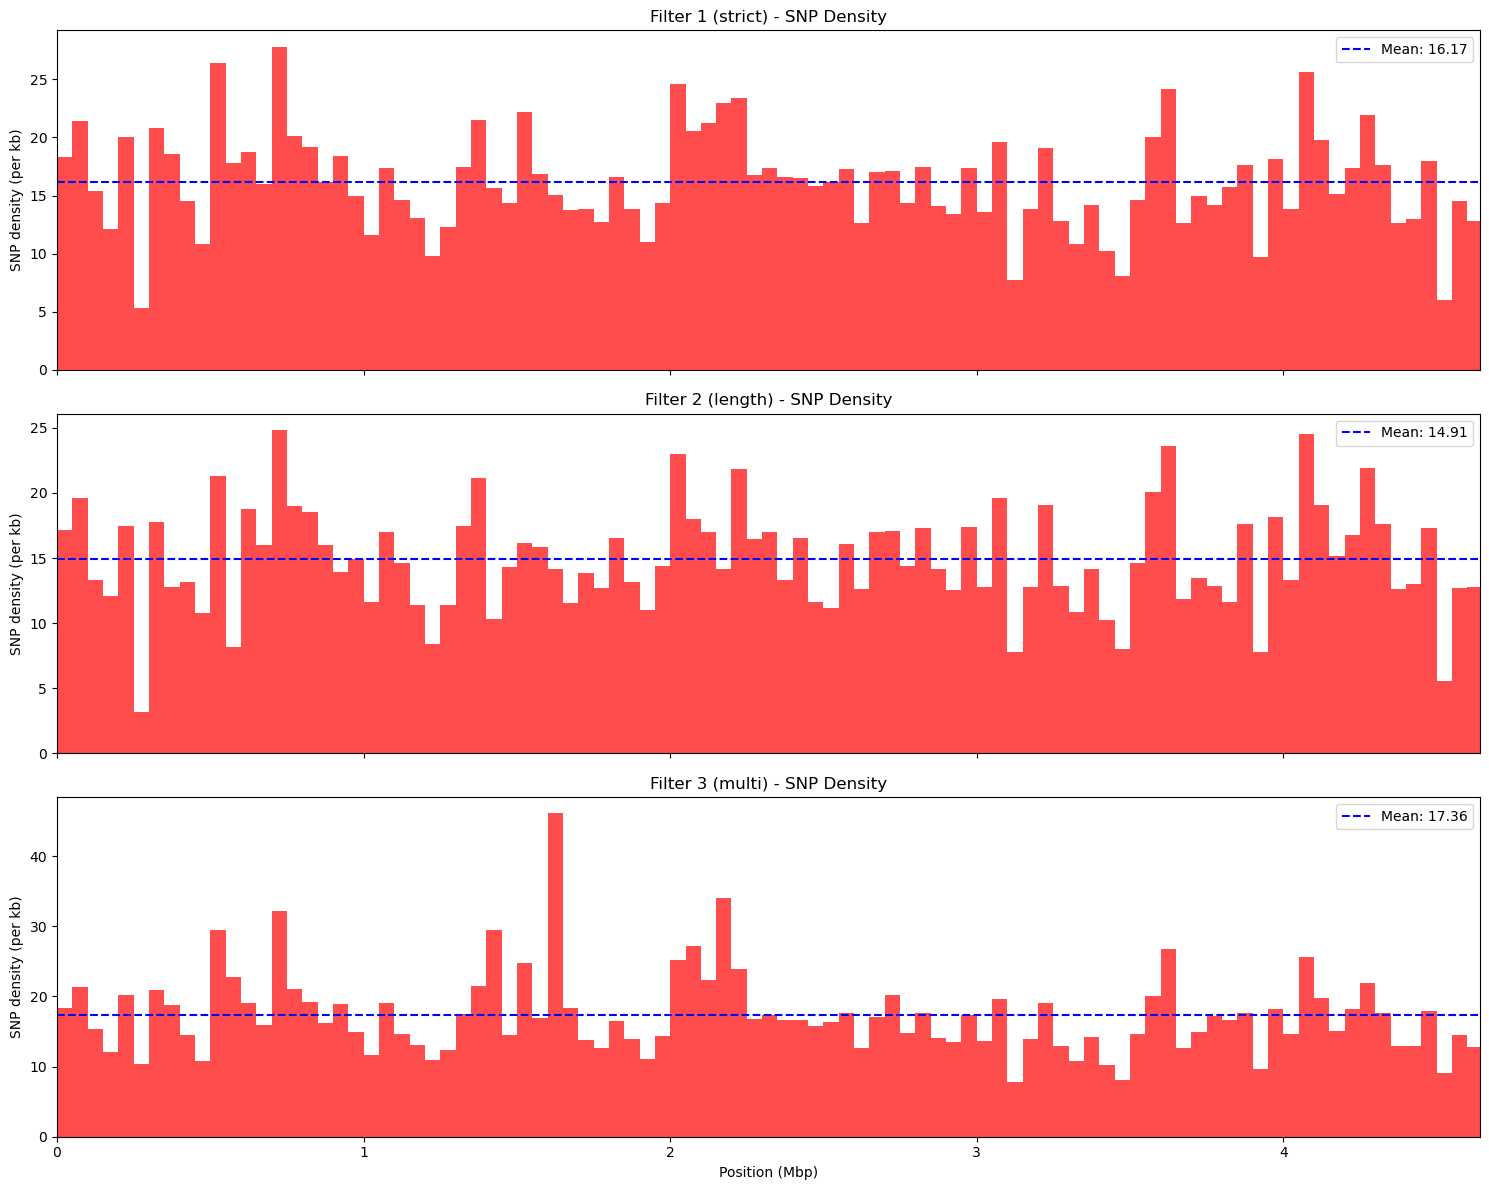

In [24]:
files = {
    "Filter 1 (strict)": "snps_filt1.tsv",
    "Filter 2 (length)": "snps_filt2.tsv",
    "Filter 3 (multi)": "snps_multi.tsv"
}
window_size_bp = 50000
window_size_kb = window_size_bp / 1000

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, (title, filename) in zip(axes, files.items()):
    df = pd.read_csv(filename, sep='\t', skiprows=4, header=None)
    
    positions_bp = df[0] 
    
    positions_mbp = positions_bp / 1_000_000
    
    max_mbp = positions_mbp.max()
    window_mbp = window_size_bp / 1_000_000
    bins = np.arange(0, max_mbp + window_mbp, window_mbp)
    
    counts, _ = np.histogram(positions_mbp, bins=bins)
    
    density = counts / window_size_kb
    
    ax.bar(bins[:-1], density, width=window_mbp, align='edge', color='red', alpha=0.7)
    
    mean_density = density.mean()
    ax.axhline(mean_density, color='blue', linestyle='--', 
               label=f'Mean: {mean_density:.2f}')
    
    ax.set_title(f"{title} - SNP Density")
    ax.set_ylabel("SNP density (per kb)")
    ax.set_xlim(0, max_mbp)
    ax.legend()

axes[-1].set_xlabel("Position (Mbp)")

plt.tight_layout()
plt.show()

### Часть 2 — Аннотация SNP — 3 балла

Извлекаем и мутируем кодоны...
Транслируем аминокислоты...

=== ТОП-10 ГЕНОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ SNP ===
      count
Gene       
ybgQ    430
rhsD    410
yeeJ    254
ybgO    218
yehI    191
ybgP    165
yjgL    139
yfaL    139
entF    131
metH    109


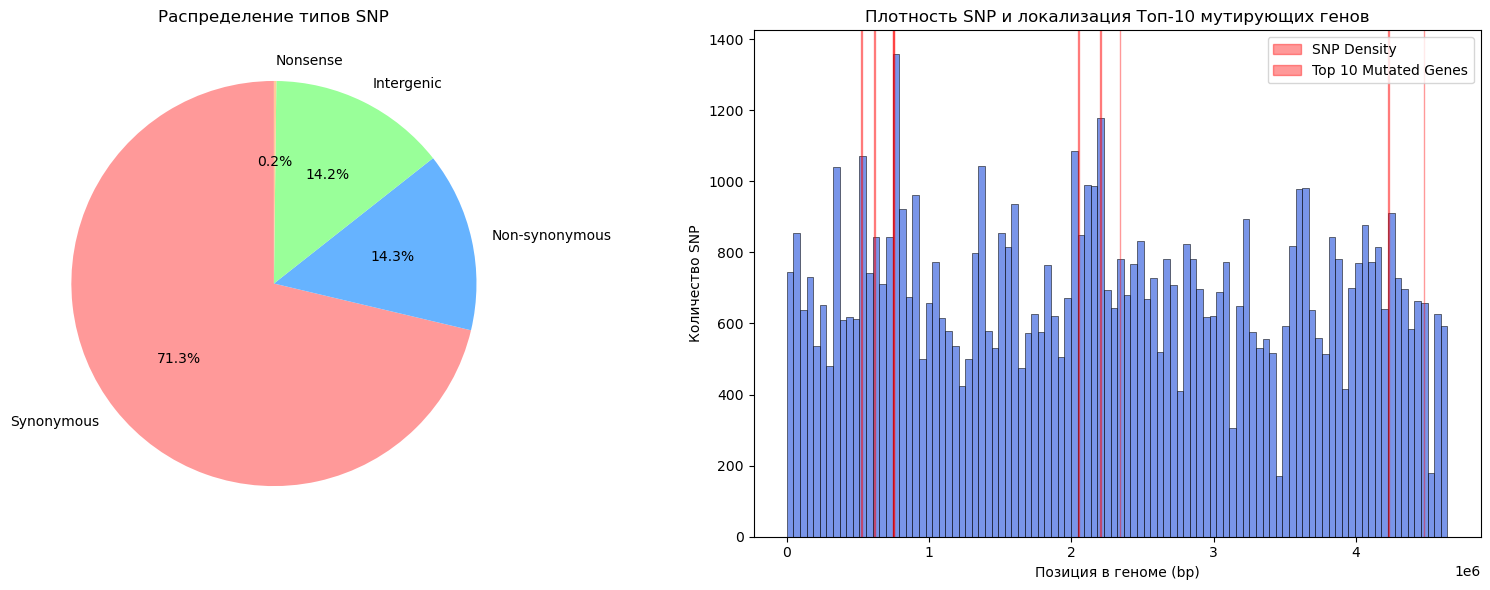

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq


gb_file = "genomic.gbff"
record = SeqIO.read(gb_file, "genbank") #seqio это парсер который позволяет из кривого файла генбанк получить удобный df

cds_features = [f for f in record.features if f.type == "CDS"]

snps_df = pd.read_csv("snps_filt1.tsv", sep='\t', skiprows=4, header=None)
snps = snps_df[[0, 1, 2]].rename(columns={0: 'Pos', 1: 'Ref', 2: 'Alt'})
snps = snps[(snps['Ref'] != '.') & (snps['Alt'] != '.')]


gene_data = []
for f in cds_features:
    gene_data.append({
        'Start': int(f.location.start),
        'End': int(f.location.end),
        'Strand': f.location.strand,
        'Gene': f.qualifiers.get("gene", f.qualifiers.get("locus_tag", ["Unknown"]))[0],
        'Product': f.qualifiers.get("product", ["Unknown function"])[0],
        'GeneSeq': str(f.extract(record.seq)) 
    })

genes_df = pd.DataFrame(gene_data)

snps['Pos_0'] = snps['Pos'] - 1 #в mummer нумерация с единички


starts = genes_df['Start'].values
ends = genes_df['End'].values

def find_gene_idx(p): #на вход кладём номер нуклеотида и получаем в каком промежутке из аннотированного генома он лежит
    matches = np.where((starts <= p) & (ends > p))[0]
    return matches[0] if len(matches) > 0 else np.nan

snps['Gene_Idx'] = snps['Pos_0'].map(find_gene_idx)

# Отделяем межгенные SNP
non_coding = snps[snps['Gene_Idx'].isna()].copy() #isna там где нет гена
non_coding[['Gene', 'Type', 'AA_Change', 'Impact', 'Function']] = ['Intergenic', 'Intergenic', '-', 'NONE', '-']

#находим генные SNP
cds = snps[snps['Gene_Idx'].notna()].copy() #notna так как гены
cds['Gene_Idx'] = cds['Gene_Idx'].astype(int)

#соединяем аннотации с snp(кодирующими)
cds = cds.merge(genes_df, left_on='Gene_Idx', right_index=True)

# создаём маску с генами с прямой цепи
is_forward = cds['Strand'] == 1

# Считаем позицию в гене
cds['Seq_Idx'] = np.where(is_forward,
                          cds['Pos_0'] - cds['Start'],
                          cds['End'] - 1 - cds['Pos_0']) #тут такая формула потому что биоконда начинает нумерацию с 1

# комплементарная замена для обратной цепи через маппинг словаря
complement = {'A':'T', 'T':'A', 'G':'C', 'C':'G'}
cds['Alt_Str'] = np.where(is_forward, cds['Alt'], cds['Alt'].map(complement))

# Вычисляем старт кодона
cds['Codon_Start'] = cds['Seq_Idx'] - (cds['Seq_Idx'] % 3)

# Функция извлечения кодонов (через itertuples работает в разы быстрее apply)
def extract_codons(row):
    start = row.Codon_Start
    codon = row.GeneSeq[start:start+3]
    if len(codon) != 3: return None, None
    mut = list(codon)
    mut[row.Seq_Idx % 3] = row.Alt_Str
    return codon, "".join(mut)

print("Извлекаем и мутируем кодоны...")
codons = [extract_codons(r) for r in cds.itertuples()]
cds['Ref_Codon'] = [c[0] for c in codons]
cds['Alt_Codon'] = [c[1] for c in codons]

cds = cds.dropna(subset=['Ref_Codon']) # Убираем краевые ошибки аннотации

# Массовая трансляция кодонов
print("Транслируем аминокислоты...")
cds['Ref_AA'] = cds['Ref_Codon'].map(lambda x: str(Seq(x).translate()))
cds['Alt_AA'] = cds['Alt_Codon'].map(lambda x: str(Seq(x).translate()))
cds['AA_Pos'] = (cds['Seq_Idx'] // 3) + 1

cds['Is_Syn'] = cds['Ref_AA'] == cds['Alt_AA']
cds['Type'] = np.where(cds['Is_Syn'], 'Synonymous', 'Non-synonymous')
cds['Type'] = np.where(cds['Alt_AA'] == '*', 'Nonsense', cds['Type'])

# Сборка красивых названий
cds['AA_Change'] = 'p.' + cds['Ref_AA'] + cds['AA_Pos'].astype(str) + cds['Alt_AA']

cds['Impact'] = np.where(cds['Is_Syn'], 'LOW', 'MODERATE/HIGH')
cds['Impact'] = np.where(cds['Alt_AA'] == '*', 'HIGH (Nonsense)', cds['Impact'])

# Собираем данные обратно в единую таблицу
cds = cds.rename(columns={'Product': 'Function'})
final_cols = ['Pos', 'Ref', 'Alt', 'Gene', 'Type', 'AA_Change', 'Impact', 'Function']
results_df = pd.concat([cds[final_cols], non_coding[final_cols]]).sort_values('Pos')

# --- 5. ВЫВОД И ВИЗУАЛИЗАЦИЯ ---
print("\n=== ТОП-10 ГЕНОВ С НАИБОЛЬШИМ КОЛИЧЕСТВОМ SNP ===")
top_genes = results_df[results_df['Gene'] != 'Intergenic']['Gene'].value_counts().head(10)
print(top_genes.to_frame())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

type_counts = results_df['Type'].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99', '#ffcc99']
ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
ax1.set_title('Распределение типов SNP')

sns.histplot(data=results_df, x='Pos', bins=100, color='royalblue', alpha=0.7, ax=ax2, label='SNP Density')

top_genes_list = top_genes.index.tolist()
for f in cds_features:
    gene_name = f.qualifiers.get("gene", f.qualifiers.get("locus_tag", [""]))[0]
    if gene_name in top_genes_list:
        ax2.axvspan(f.location.start, f.location.end, color='red', alpha=0.4)

ax2.set_title('Плотность SNP и локализация Топ-10 мутирующих генов')
ax2.set_xlabel('Позиция в геноме (bp)')
ax2.set_ylabel('Количество SNP')
ax2.legend(['SNP Density', 'Top 10 Mutated Genes'])

plt.tight_layout()
plt.show()


#### Часть 3 — Поиск функционально значимых SNP — 4 балла


Я взял тему про тяжёлые металлы и вот эту статью - https://pmc.ncbi.nlm.nih.gov/articles/PMC11137339/.

Статья на самом деле о вляинии многих факторов на транскриптом, но особое внимание уделю именно тяжёлым металлам.

Основные инсайты статьи  - что в ответ на воздействие тяжёлых металлов бактерии повышают частоту мутаций готовя адаптивные варианты.

1. Геномные изменения, особенно мутации в генах, кодирующих РНК-полимеразу и транскрипционные факторы, приводят к масштабным вариациям в транскриптоме

2. Адаптация строго специфична для каждого конкретного металла. Устойчивость к свинцу достигается мутациями в генах ABC-транспортеров, к никелю изменениями в метаболизме азота, к хрому  в метаболизме органических кислот, а к меди в биосинтезе фолатов.

Как можно использовать это в реальной жизни? Мне кажется  просто - эти белки, на полиморфизм которых влияет содержание тяжёлых металлов, могут использоваться как мишени для антимикробных препаратов. И чем больше у нас есть вариаций в базе, тем с большей точностью мы сможем прикинуть, насколько хорошим будет лекарство. Ведь именно благодаря полиморфизмам и изменчивости популяция остаётся устойчивой к препарату: всегда найдётся мразота с такой мутацией, для которой белок-мишень уже с лекарством не связывается. Если постараться учесть все SNP при создании лекарства под мишень, можно значительно продлить его эффективность.